/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Forecast for the next 12 months:
1961-01-01    449.330269
1961-02-01    424.386564
1961-03-01    459.033907
1961-04-01    497.865803
1961-05-01    509.863877
1961-06-01    568.258851
1961-07-01    655.811113
1961-08-01    641.191479
1961-09-01    546.393734
1961-10-01    496.801909
1961-11-01    427.675571
1961-12-01    471.237421
Freq: MS, Name: predicted_mean, dtype: float64


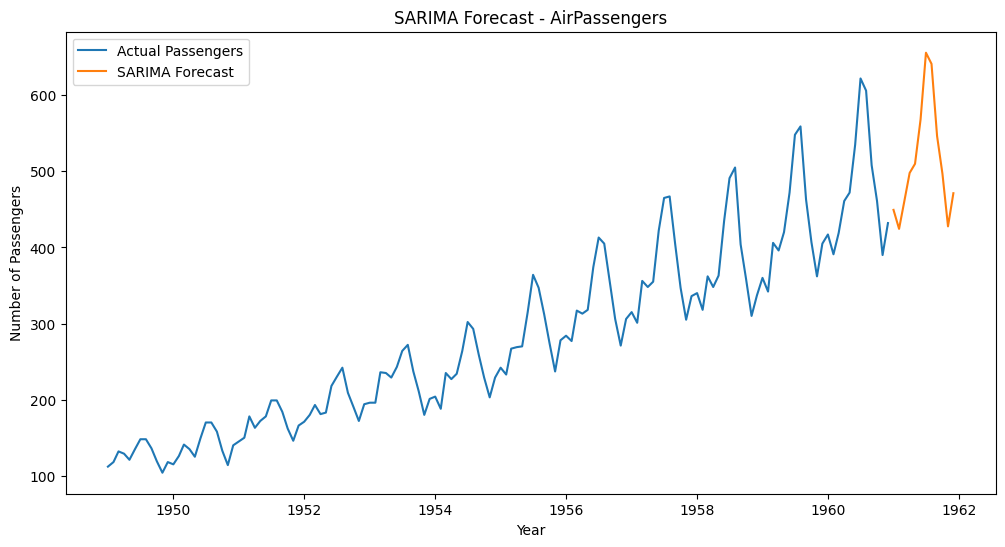

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load AirPassengers dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# Convert Month to datetime
df['Month'] = pd.to_datetime(df['Month'])

# Set Month as index
df.set_index('Month', inplace=True)

# Create monthly time series
ts = df['Passengers']

# Build SARIMA model
# (p,d,q) = (1,1,1)
# (P,D,Q,12) = (1,1,1,12)
model = SARIMAX(
    ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)

# Train the model
model_fit = model.fit(disp=False)

# Forecast next 12 months
forecast = model_fit.forecast(steps=12)

# Print forecast values
print("Forecast for the next 12 months:")
print(forecast)

# Visualize original data and forecast
plt.figure(figsize=(12, 6))
plt.plot(ts, label='Actual Passengers')
plt.plot(forecast, label='SARIMA Forecast')
plt.title('SARIMA Forecast - AirPassengers')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()